# Scikit-learn-compatible vine-copula estimators

This notebook walks through `VineDensity` and `VineRegressor`, the two single-vine estimators that ship with the `pyvinecopulib.sklearn` extra. Both are thin scikit-learn wrappers around `pyvinecopulib.core.Vinecop` and `pyvinecopulib.utils.Kde1d`, providing the standard `fit` / `predict` interface plus DataFrame handling, automatic continuous/discrete column inference, and batched evaluation.

All vine copula models are built on Sklar's theorem, which factorises a joint density into one-dimensional marginals and a copula on the unit hypercube,

$$f(\mathbf{x}) = c\bigl(F_1(x_1), \ldots, F_d(x_d)\bigr) \, \prod_{j=1}^{d} f_j(x_j).$$

The marginals $F_j$ / $f_j$ are estimated by univariate KDE (see `Kde1d`), and the dependence structure $c$ is decomposed into a tree of bivariate "pair-copulas" — the vine. See the `pyvinecopulib.core` and `pyvinecopulib.families` module docs for the underlying machinery; this notebook focuses on the sklearn-facing interface.

Data: [California Housing](https://scikit-learn.org/stable/datasets/real_world.html#california-housing-dataset) (subsetted for runtime). The same regression flow is used in the experiments of Vatter & Nagler (2026) — minus the model-confidence-set ensembling, which is the subject of the companion forest notebook.

In [1]:
import pytest

pytest.importorskip("sklearn")
pytest.importorskip("pandas")

import time  # noqa: E402

import matplotlib.pyplot as plt  # noqa: E402
import numpy as np  # noqa: E402
from sklearn.datasets import fetch_california_housing  # noqa: E402
from sklearn.linear_model import LinearRegression  # noqa: E402
from sklearn.metrics import (  # noqa: E402
  mean_absolute_error,
  root_mean_squared_error,
)
from sklearn.model_selection import train_test_split  # noqa: E402
from sklearn.preprocessing import StandardScaler  # noqa: E402

from pyvinecopulib.sklearn import VineDensity, VineRegressor  # noqa: E402

rng = np.random.default_rng(0)

## Data

We subsample 2000 rows from California Housing and standard-scale the covariates. Vines are themselves scale-equivariant (the `Kde1d` marginal step absorbs any monotone transform), so scaling is purely there to keep the comparison with the linear baseline fair.

In [2]:
X_full, y_full = fetch_california_housing(return_X_y=True)
idx = rng.choice(X_full.shape[0], size=2000, replace=False)
X, y = X_full[idx], y_full[idx]

X_train, X_test, y_train, y_test = train_test_split(
  X, y, test_size=0.25, random_state=42
)
scaler = StandardScaler().fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)
print(f"train: {X_train.shape}, test: {X_test.shape}")

train: (1500, 8), test: (500, 8)


## Regression: conditional mean + quantiles

`VineRegressor.fit(X, y)` fits a vine copula to the joint distribution of $(Y, X)$. Predictions then follow the estimating-equation framework of Nagler & Vatter (2024): for any functional $\beta(x)$ characterised by $\mathbb{E}[\psi_\beta(Y) \mid X = x] = 0$, we plug in the fitted conditional density and solve $\int \psi_\beta(y) \, \hat f(y \mid x) \, dy = 0$. Two standard choices of $\psi_\beta$ recover familiar predictors,

$$\psi_\beta(y) = y - \beta \;\Rightarrow\; \beta(x) = \mathbb{E}[Y \mid X = x], \quad\quad \psi_\beta(y) = \mathbf{1}\{y < \beta\} - \tau \;\Rightarrow\; \beta(x) = Q_\tau(Y \mid X = x).$$

Both reduce in practice to a weighted average of the training responses with weights $w_i(x) \propto c_{Y, X}(\hat F_Y(y_i), \hat F_X(x))$ derived from the fitted copula density — closed-form for the mean, and `np.quantile(..., weights=..., method="inverted_cdf")` for the conditional quantiles.

`predict(X)` returns the requested statistics column by column: mean first (when `mean=True`), then the quantiles in the order configured at construction.

In [3]:
quantiles = np.linspace(
  0.05, 0.95, 19
)  # 5%, 10%, ..., 95% — odd count for CRPS
median_col = 1 + int(np.argmin(np.abs(quantiles - 0.5)))

t0 = time.time()
reg = VineRegressor(mean=True, quantiles=quantiles).fit(X_train, y_train)
print(f"VineRegressor fit: {time.time() - t0:.1f}s")
t0 = time.time()
y_pred = reg.predict(X_test)
print(f"VineRegressor predict: {time.time() - t0:.1f}s")
print(f"prediction columns: mean | q5 | q10 | ... | q95 — shape={y_pred.shape}")

VineRegressor fit: 1.0s


VineRegressor predict: 7.9s
prediction columns: mean | q5 | q10 | ... | q95 — shape=(500, 20)


We score predictions with three standard metrics. RMSE evaluates the mean column, MAE evaluates the median, and the continuous ranked probability score (CRPS) summarises the entire quantile forecast,

$$\mathrm{CRPS}(F, y) \;=\; \int_0^1 \bigl(\alpha - \mathbf{1}\{y < F^{-1}(\alpha)\}\bigr) \bigl(y - F^{-1}(\alpha)\bigr) \, d\alpha,$$

approximated below by Simpson's rule on our 19-quantile grid. We compare against an ordinary `LinearRegression` as a baseline; the linear model produces only a point estimate, so its MAE uses that single prediction and its CRPS is undefined.

In [4]:
def crps_from_quantiles(y_true, q, alphas):
  """Mean CRPS via Simpson integration over a uniform quantile grid."""
  n, M = q.shape
  assert M % 2 == 1, "Simpson's rule needs an odd number of points."
  h = (alphas[-1] - alphas[0]) / (M - 1)
  U = y_true[:, None] - q
  pinball = (alphas[None, :] - (U < 0)) * U
  w = np.ones(M)
  w[1:-1:2] = 4
  w[2:-1:2] = 2
  return float(2 * ((h / 3.0) * (pinball * w[None, :]).sum(axis=1)).mean())


lin = LinearRegression().fit(X_train, y_train)
y_pred_lin = lin.predict(X_test)

scores = {
  "RMSE (mean)": (
    root_mean_squared_error(y_test, y_pred[:, 0]),
    root_mean_squared_error(y_test, y_pred_lin),
  ),
  "MAE (median)": (
    mean_absolute_error(y_test, y_pred[:, median_col]),
    mean_absolute_error(y_test, y_pred_lin),
  ),
  "CRPS": (
    crps_from_quantiles(y_test, y_pred[:, 1:], quantiles),
    float("nan"),  # linear regression doesn't produce quantiles
  ),
}

print(f"{'metric':<14} {'VineRegressor':>14} {'LinearReg':>10}")
for name, (vine, lin_score) in scores.items():
  lin_str = "—" if np.isnan(lin_score) else f"{lin_score:.3f}"
  print(f"{name:<14} {vine:>14.3f} {lin_str:>10}")

metric          VineRegressor  LinearReg
RMSE (mean)             0.662      0.701
MAE (median)            0.467      0.503
CRPS                    0.331          —


Because `VineRegressor` exposes the standard sklearn `fit` / `predict` interface, it slots into any `sklearn.pipeline.Pipeline` — useful for prepending feature selection (e.g. `SelectFdr`) or feature transforms before the vine.

## Density estimation

`VineDensity.fit(X)` fits a vine copula to the joint distribution of every column of `X`. The factorisation from Sklar's theorem above means the resulting density is a product of seven $\mathrm{Kde1d}$ marginal densities times a copula density on $[0, 1]^d$ encoding their dependence — and once fitted we can both **evaluate** it (`score_samples`, `pdf`, `cdf`) and **sample** from it.

To turn the regression dataset into a generative model we stack the response onto the covariates so `VineDensity` treats $Y$ as just another marginal.

In [5]:
joint_train = np.hstack([X_train, y_train.reshape(-1, 1)])
joint_test = np.hstack([X_test, y_test.reshape(-1, 1)])

t0 = time.time()
dens = VineDensity().fit(joint_train)
print(f"VineDensity fit: {time.time() - t0:.1f}s")

nll_test = -float(dens.score_samples(joint_test).mean())
print(f"test NLL: {nll_test:.3f}")
print(
  f"pdf range on test: [{dens.pdf(joint_test).min():.2e}, {dens.pdf(joint_test).max():.2e}]"
)

VineDensity fit: 1.1s
test NLL: 6.605
pdf range on test: [7.48e-22, 3.81e-01]


### Sampling

A density estimator that captures dependence should generate synthetic data whose pairwise structure matches the training set. The pair plot below superimposes 1000 draws from `dens.sample(...)` on the training data for three representative columns (median income, average rooms per dwelling, and the response `MedHouseVal`). The diagonal panels show marginal histograms; the off-diagonals show scatter plots, which is where dependence is visible.

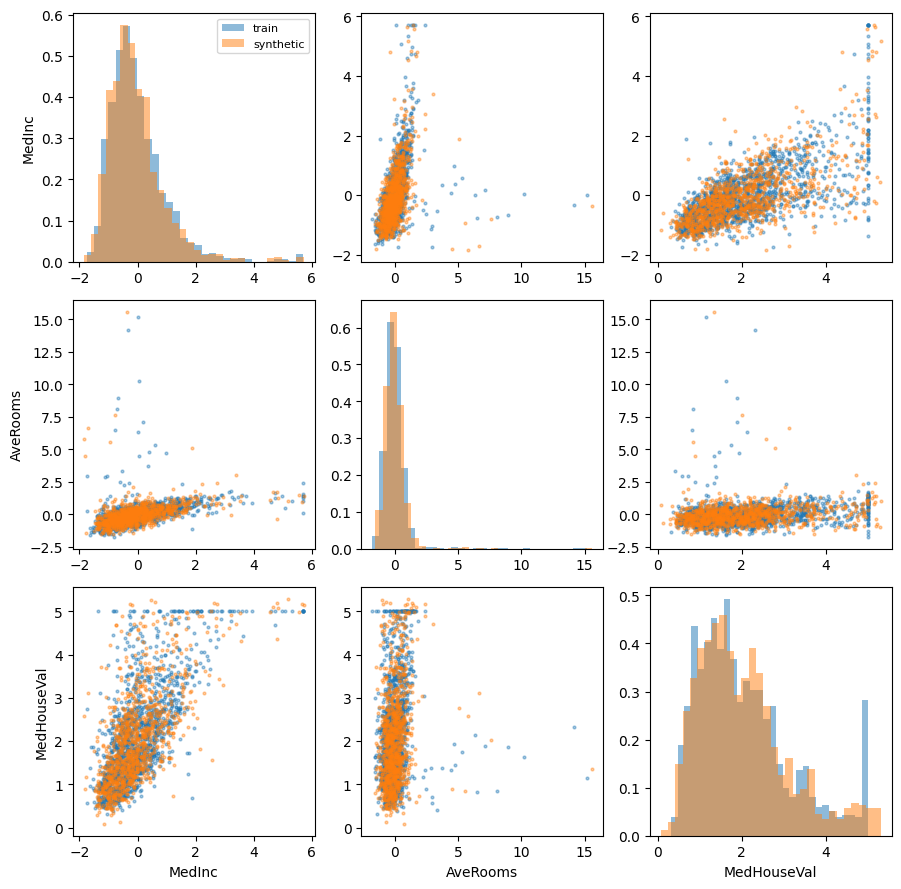

In [6]:
synth = dens.sample(n_samples=1000, random_state=42)

# Pick three informative columns: feature 0 (MedInc), feature 2 (AveRooms), target.
cols_idx = [0, 2, 8]
col_names = ["MedInc", "AveRooms", "MedHouseVal"]
d = len(cols_idx)

fig, axes = plt.subplots(d, d, figsize=(3 * d, 3 * d))
for i in range(d):
  for j in range(d):
    ax = axes[i, j]
    ci, cj = cols_idx[i], cols_idx[j]
    if i == j:
      ax.hist(
        joint_train[:, ci], bins=30, density=True, alpha=0.5, label="train"
      )
      ax.hist(synth[:, ci], bins=30, density=True, alpha=0.5, label="synthetic")
      if i == 0:
        ax.legend(fontsize=8)
    else:
      ax.scatter(
        joint_train[:, cj], joint_train[:, ci], s=4, alpha=0.4, label="train"
      )
      ax.scatter(synth[:, cj], synth[:, ci], s=4, alpha=0.4, label="synthetic")
    if i == d - 1:
      ax.set_xlabel(col_names[j])
    if j == 0:
      ax.set_ylabel(col_names[i])
plt.tight_layout()

### Joint CDF

`cdf` is quasi-Monte-Carlo and so noisy at small `N`; pass `seeds` for reproducibility and bump `N` if the noise floor matters. The joint CDF is small at random points in $\mathbb{R}^9$ (each marginal contributes a factor $\le 1$), so we evaluate at marginal quantiles where the expected monotone behaviour is easier to see.

In [7]:
qs = np.linspace(0.1, 0.9, 5)
# Build points where every coordinate sits at the same marginal quantile.
grid = np.column_stack(
  [np.quantile(joint_train[:, j], qs) for j in range(joint_train.shape[1])]
)
cdf_grid = dens.cdf(grid, N=20000, random_state=0)

print(f"{'marginal quantile':>18}  {'joint CDF':>10}")
for q_lvl, F_val in zip(qs, cdf_grid):
  print(f"{q_lvl:>18.2f}  {F_val:>10.4f}")

 marginal quantile   joint CDF
              0.10      0.0000
              0.30      0.0000
              0.50      0.0001
              0.70      0.0273
              0.90      0.4228


## What's next

- For ensembles of these single-vine estimators with model-confidence-set selection, see `09_sklearn_forest.ipynb`.
- For low-level control beyond what the sklearn wrappers expose (custom `FitControlsVinecop`, hand-crafted `RVineStructure`, raw `Vinecop.pdf` on pseudo-observations), reach for `pyvinecopulib.core` directly.